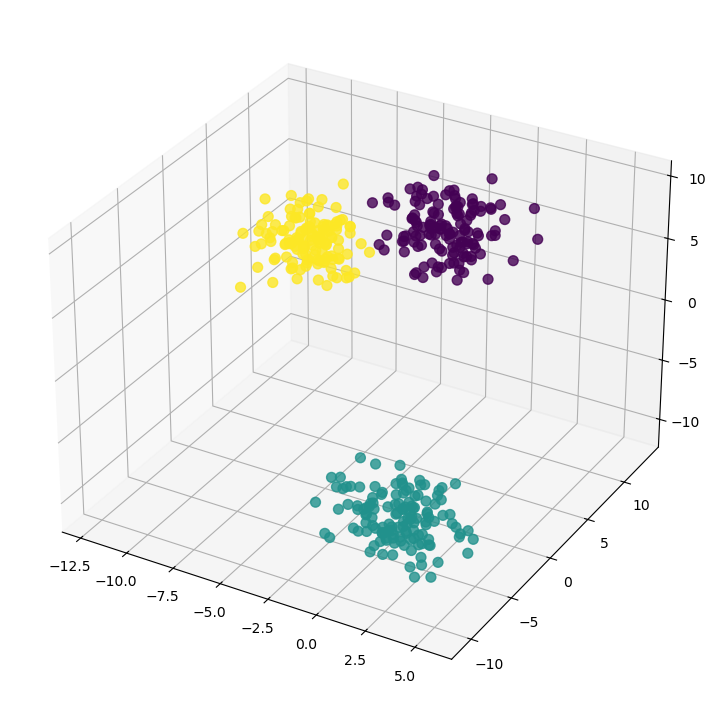

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate 3 clusters in 3D
num_points = 400
points_blobs, labels_blobs = make_blobs(
    n_samples=num_points, centers=3, n_features=3, cluster_std=1.5, random_state=42
)
# Generate 3D points
points = points_blobs

# Create a 3D scatter plot using matplotlib
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Create scatter plot
scatter = ax.scatter(
    points[:, 0],
    points[:, 1],
    points[:, 2],
    c=labels_blobs,
    cmap="viridis",
    s=50,
    alpha=0.8,
)

# Add labels and title
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")
# ax.set_title("3D Blob Clusters")

# Add colorbar
# plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=20)

# Save as high-quality PDF
plt.savefig(
    "3d_blob_clusters_matplotlib.pdf", format="pdf", dpi=300, bbox_inches="tight"
)

plt.show()


In [2]:
from scipy.spatial.distance import pdist, squareform

D_blobs = squareform(pdist(points_blobs))
print("blobs:", points_blobs.shape, "distance matrix:", D_blobs.shape)
print("max distance:", np.max(D_blobs), "min distance:", np.min(D_blobs))

blobs: (400, 3) distance matrix: (400, 400)
max distance: 27.982695131426077 min distance: 0.0


In [3]:
import abmph

# build a bi-filtration from a point cloud
bifi = abmph.BiFiltration(
    filtration_type="ball_density",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    # file_path="../experiment/data/PointCloud/annulus_400.txt",
    points=points_blobs,
)

# then you can compute the MPH0 from the graded graph
graded_graph = bifi.ggraph
res = abmph.compute_MPH0(graded_graph)

# in order to plot, you need to get the x and y coordinates of the points
table_x_coords = bifi.get_x_coords()  # ball density function
table_y_coords = bifi.get_y_coords()  # distance

In [4]:
# More efficient implementation using numpy's cumsum
def compute_2d_prefix_sum(binary_matrix):
    """
    More efficient 2D prefix sum using numpy's cumsum function.

    Args:
        binary_matrix: 2D numpy array of 0s and 1s

    Returns:
        H: 2D numpy array where H[i,j] is the cumulative count
    """
    # First compute cumulative sum along rows (axis=1)
    row_cumsum = np.cumsum(binary_matrix, axis=1)

    # Then compute cumulative sum along columns (axis=0)
    H = np.cumsum(row_cumsum, axis=0)

    return H

In [5]:
from abmph import convert_betti_numbers_to_2d_array


def betti_res_to_matrix(absolute_betti_numbers_result_dict, m, n):
    b_0_array = convert_betti_numbers_to_2d_array(
        absolute_betti_numbers_result_dict["b_0"], m, n
    )
    b_1_array = convert_betti_numbers_to_2d_array(
        absolute_betti_numbers_result_dict["b_1"], m, n
    )
    b_2_array = convert_betti_numbers_to_2d_array(
        absolute_betti_numbers_result_dict["b_2"], m, n
    )
    return b_0_array, b_1_array, b_2_array


m, n = len(table_x_coords), len(table_y_coords)
b0_arr, b1_arr, b2_arr = betti_res_to_matrix(res, m, n)

presum_b0_arr = compute_2d_prefix_sum(b0_arr)
presum_b1_arr = compute_2d_prefix_sum(b1_arr)
presum_b2_arr = compute_2d_prefix_sum(b2_arr)

hilbert_matrix = presum_b0_arr - presum_b1_arr + presum_b2_arr
hilbert_matrix.shape

(106, 79801)

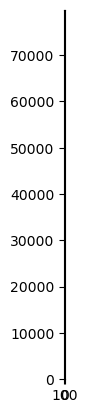

In [6]:
import matplotlib.pyplot as plt

plt.imshow(hilbert_matrix.T, origin="lower")

In [7]:
# locate the min value in hilbert_matrix
min_value_index = np.unravel_index(np.argmin(hilbert_matrix), hilbert_matrix.shape)
print(min_value_index, hilbert_matrix[min_value_index])


(0, 0) 1


It is hard to visualize due to the large shape difference. Let's try to use filtration values to merge the axes. 

In [8]:
def test_compute_approximated_Hilbert_matrix(
    res: dict[str, list[tuple[int, int]]],
    table_x_coords: list[float],
    table_y_coords: list[float],
    target_matrix_shape: tuple[int, int],
):
    # convert the graded betti numbers in indices to filtration values
    b_0_values = abmph.map_graded_betti_numbers_to_filtration_values(
        res["b_0"], table_x_coords, table_y_coords
    )
    b_0_values = np.array(b_0_values)  # of shape ( _ ,2)
    b_1_values = abmph.map_graded_betti_numbers_to_filtration_values(
        res["b_1"], table_x_coords, table_y_coords
    )
    b_1_values = np.array(b_1_values)
    b_2_values = abmph.map_graded_betti_numbers_to_filtration_values(
        res["b_2"], table_x_coords, table_y_coords
    )
    b_2_values = np.array(b_2_values)

    target_m, target_n = target_matrix_shape
    xs = np.linspace(table_x_coords[0], table_x_coords[-1], target_m)
    ys = np.linspace(table_y_coords[0], table_y_coords[-1], target_n)
    matrix_meshgrid = np.meshgrid(xs, ys, indexing="ij")

    cumsum_b_0 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_1 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_2 = np.zeros((target_m, target_n), dtype=np.int32)
    for i in range(target_m):
        for j in range(target_n):
            s, k = matrix_meshgrid[0][i][j], matrix_meshgrid[1][i][j]
            # counts the number of rows (x,y) in b_0_values that satisfy x <= s and y <= k
            cumsum_b_0[i, j] = np.sum((b_0_values[:, 0] <= s) & (b_0_values[:, 1] <= k))
            cumsum_b_1[i, j] = np.sum((b_1_values[:, 0] <= s) & (b_1_values[:, 1] <= k))
            cumsum_b_2[i, j] = np.sum((b_2_values[:, 0] <= s) & (b_2_values[:, 1] <= k))

    return cumsum_b_0, cumsum_b_1, cumsum_b_2


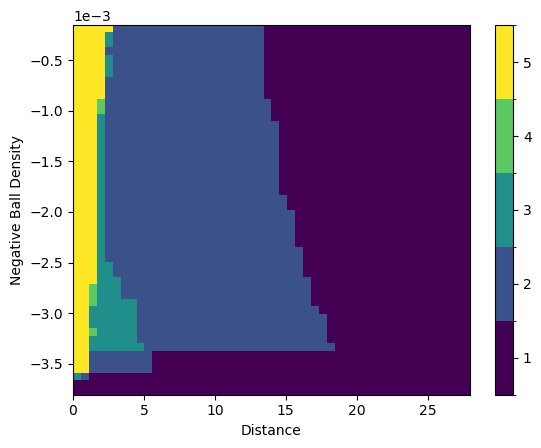

In [9]:
# build a bi-filtration from a point cloud
bifi = abmph.BiFiltration(
    filtration_type="ball_density",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    # file_path="../experiment/data/PointCloud/annulus_400.txt",
    points=points_blobs,
)

# then you can compute the MPH0 from the graded graph
graded_graph = bifi.ggraph
res = abmph.compute_MPH0(graded_graph)

# in order to plot, you need to get the x and y coordinates of the points
table_x_coords = bifi.get_x_coords()  # ball density function
table_y_coords = bifi.get_y_coords()  # distance

cum_0, cum_1, cum_2 = test_compute_approximated_Hilbert_matrix(
    res, table_x_coords, table_y_coords, (50, 50)
)

approx_hilbert_matrix = cum_0 - cum_1 + cum_2
# map the value greater to 4 to 4
approx_hilbert_matrix = np.clip(approx_hilbert_matrix, 0, 5)
# matrix_to_plot = np.log(approx_hilbert_matrix + 1)
matrix_to_plot = approx_hilbert_matrix

# plot the approximated Hilbert matrix (distance vs ball density)
xrange = np.min(table_x_coords), np.max(table_x_coords)
yrange = np.min(table_y_coords), np.max(table_y_coords)
discrete_plot, cbar = abmph.draw_discrete_matrix(
    matrix_to_plot, x_axis_range=yrange, y_axis_range=xrange, origin="lower"
)

# Format axes to use scientific notation
# discrete_plot.ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))
discrete_plot.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

discrete_plot.xlabel("Distance")
discrete_plot.ylabel("Negative Ball Density")

discrete_plot.savefig("Hibert_matrix_ball_density_rips_blob_400.pdf", dpi=300)
discrete_plot.show()

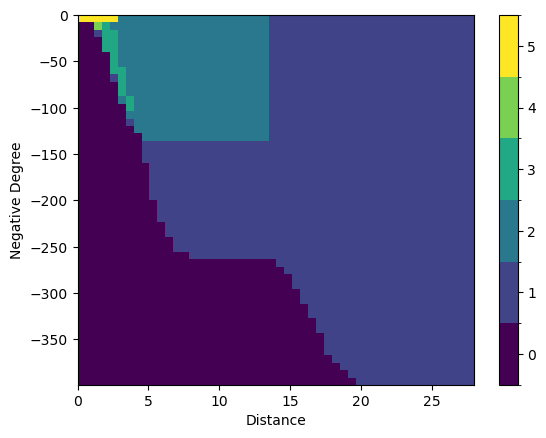

In [10]:
import abmph

# build a bi-filtration from a point cloud
bifi = abmph.BiFiltration(
    filtration_type="degree",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    # file_path="../experiment/data/PointCloud/annulus_400.txt",
    points=points_blobs,
)

# then you can compute the MPH0 from the graded graph
graded_graph = bifi.ggraph
res = abmph.compute_MPH0(graded_graph)

# in order to plot, you need to get the x and y coordinates of the points
table_x_coords = bifi.get_x_coords()  # distance
table_y_coords = bifi.get_y_coords()  # -degree

# compute the approximated Hilbert matrix
cum_0, cum_1, cum_2 = test_compute_approximated_Hilbert_matrix(
    res, table_x_coords, table_y_coords, (50, 50)
)

approx_hilbert_matrix = cum_0 - cum_1 + cum_2
# map the value greater to 4 to 4
approx_hilbert_matrix = np.clip(approx_hilbert_matrix, 0, 5)
# matrix_to_plot = np.log(approx_hilbert_matrix + 1)
matrix_to_plot = approx_hilbert_matrix

# plot the approximated Hilbert matrix (distance vs -degree)
xrange = np.min(table_x_coords), np.max(table_x_coords)
yrange = np.min(table_y_coords), np.max(table_y_coords)
discrete_plot, cbar = abmph.draw_discrete_matrix(
    matrix_to_plot.T, x_axis_range=xrange, y_axis_range=yrange, origin="lower"
)

# Format axes to use scientific notation
# discrete_plot.ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))
# discrete_plot.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

discrete_plot.xlabel("Distance")
discrete_plot.ylabel("Negative Degree")
# discrete_plot.tight_layout()
discrete_plot.savefig("Hibert_matrix_degree_rips_blob_400.pdf", dpi=300)
discrete_plot.show()